<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/04_learning_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### 4 - Learning Curves
**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

This notebook, contains the visualizations regarding the project, mainly the learning curves but also smaller plots to support the report.

**Observation:** The first cell of code bellow was implemente to be able to run the notebook using Google Colab, while the rest o the code was initially wroten using DataSpell.

In [1]:
!rm -rf /content/TOL506M_Final_Project

In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [9]:
import sys
import os
import subprocess
import importlib
import json
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.9.0+cu126
CUDA available: True


In [25]:
# Import project modules
from config import Config

# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)

In [20]:
# Load a list of JSON summary files (each is a list of dicts)
def load_summaries(filepaths):
    """
    filepaths: list of paths to JSON files.
    Returns: list of lists of result dicts.
    """
    all_runs = []
    for fp in filepaths:
        with open(fp, "r") as f:
            all_runs.append(json.load(f))
    return all_runs

# Compute mean and asymmetric error bars from a list of values
def mean_and_range_errors(values):
    """
    values: list of floats (e.g. training times from different runs).
    Returns: (mean, lower_err, upper_err)
    where lower_err = mean - min(values), upper_err = max(values) - mean.
    """
    if not values:
        return None, None, None
    vmin = min(values)
    vmax = max(values)
    mean = sum(values) / len(values)
    lower = mean - vmin
    upper = vmax - mean
    return mean, lower, upper

task1_files = [
    "/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary.json",
    "/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_42.json",
    "/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_640.json",
]

task2_files = [
    "/content/TOL506M_Final_Project/results/metrics/task2_finetune_summary.json",
    "/content/TOL506M_Final_Project/results/metrics/task2_finetune_summary_42.json",
    "/content/TOL506M_Final_Project/results/metrics/task2_finetune_summary_640.json",
]
task3_files = [
    "/content/TOL506M_Final_Project/results/metrics/task3_1.json",
    "/content/TOL506M_Final_Project/results/metrics/task3_42.json",
    "/content/TOL506M_Final_Project/results/metrics/task3_640.json",
]

# Load all runs
task1_runs = load_summaries(task1_files)
task2_runs = load_summaries(task2_files)
task3_runs = load_summaries(task3_files)


# Aggregate training_time vs data_fraction for Task 1

# dict: data_fraction -> list of training_time across runs
task1_times = defaultdict(list)

for run in task1_runs:
    for r in run:
        task1_times[r["data_fraction"]].append(r["training_time"])

task1_records = []
for frac, vals in task1_times.items():
    mean, lo, hi = mean_and_range_errors(vals)
    task1_records.append({
        "task": "Task1",
        "freeze_layers": "scratch",
        "data_fraction": frac,
        "time_min": mean / 60,
        "err_low": lo / 60,
        "err_high": hi / 60,
        "label": "Task 1 (scratch)"
    })

# Process Task 2 (per-freeze-layer and global)
task2_times = defaultdict(lambda: defaultdict(list))

for run in task2_runs:
    for r in run:
        freeze = r["hyperparameters"]["freeze_layers"]
        frac = r["data_fraction"]
        task2_times[freeze][frac].append(r["training_time"])

task2_records = []

# Per layer
for freeze, fracs in task2_times.items():
    for frac, vals in fracs.items():
        mean, lo, hi = mean_and_range_errors(vals)
        task2_records.append({
            "task": "Task2",
            "freeze_layers": str(freeze),
            "data_fraction": frac,
            "time_min": mean / 60,
            "err_low": lo / 60,
            "err_high": hi / 60,
            "label": f"Task 2 (freeze={freeze})"
        })


In [21]:
df = pd.DataFrame(task1_records + task2_records)
df

,task,freeze_layers,data_fraction,time_min,err_low,err_high,label
0,Task1,scratch,0.10,21.265638,4.105102,7.664418,Task 1 (scratch)
1,Task1,scratch,0.25,44.123553,13.431474,6.963369,Task 1 (scratch)
2,Task1,scratch,0.50,74.967911,22.617122,13.375125,Task 1 (scratch)
3,Task1,scratch,0.75,90.913256,18.261125,35.201198,Task 1 (scratch)
4,Task1,scratch,1.00,94.781169,2.395954,1.407877,Task 1 (scratch)
5,Task2,all_but_fc,0.10,11.278724,2.052837,1.438947,Task 2 (freeze=all_but_fc)
6,Task2,all_but_fc,0.25,20.362527,8.097874,7.656661,Task 2 (freeze=all_but_fc)
7,Task2,all_but_fc,0.50,40.070054,9.262003,8.268007,Task 2 (freeze=all_but_fc)
8,Task2,all_but_fc,0.75,38.709676,11.364463,7.621250,Task 2 (freeze=all_but_fc)
9,Task2,all_but_fc,1.00,56.686935,27.076574,20.869202,Task 2 (freeze=all_but_fc)


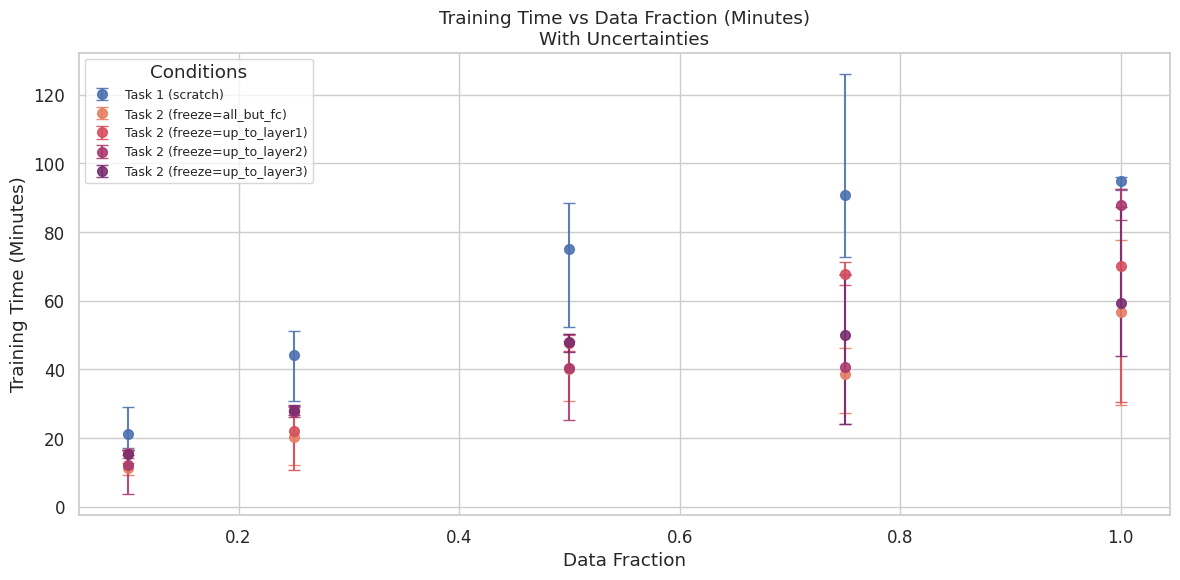

In [27]:
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(12, 6))

# Define consistent palette:
palette = {
    "Task 1 (scratch)": "C0"
}

# Identify Task 2 labels
task2_labels = [label for label in df["label"].unique() if label != "Task 1 (scratch)"]

# Generate flare palette for the number of Task 2 categories
flare_pal = sns.color_palette("flare", n_colors=len(task2_labels))

# Assign flare colours to Task 2
for label, color in zip(task2_labels, flare_pal):
    palette[label] = color

# Plot (scatter only; error bars added manually)
for label, subset in df.groupby("label"):
    plt.errorbar(
        subset["data_fraction"],
        subset["time_min"],
        yerr=[subset["err_low"], subset["err_high"]],
        fmt="o",
        markersize=7,
        linestyle="none",
        capsize=4,
        label=label,
        color=palette[label],
        alpha=0.9
    )

plt.title("Training Time vs Data Fraction (Minutes)\nWith Uncertainties")
plt.xlabel("Data Fraction")
plt.ylabel("Training Time (Minutes)")
plt.legend(title="Conditions", fontsize=9)
plt.tight_layout()
plt.savefig("results/plots/training_times_plot.png", dpi=600, bbox_inches="tight")
plt.show()